# Mustang vs. Camaro Historical Sales

A practice in SQL, Python, Pandas/NumPy, matplotlib

## Imports

In [109]:
import pandas as pd
import numpy as np
import sqlite3
import requests
import matplotlib.pyplot as plt
from datetime import datetime
from bs4 import BeautifulSoup

## Constants

In [110]:
CAMARO_URL = 'https://en.wikipedia.org/wiki/Chevrolet_Camaro'
MUSTANG_URL = 'https://en.wikipedia.org/wiki/Ford_Mustang'

# Header to bypass Wikipedia's bot-blocker
HEADERS = {
    'User-Agent': 'Car Sales Scraper/1.0 (contact: thomas.gette@outlook.com) Python-requests'
}

CAMARO_GENERATIONS = {
    "1": (1967, 1969),
    "2": (1970, 1981),
    "3": (1982, 1992),
    "4": (1993, 2002),
    "5": (2010, 2015),
    "6": (2016, 2024),
}

MUSTANG_GENERATIONS = {
    "1": (1964, 1973),
    "2": (1974, 1978),
    "3": (1979, 1993),
    "4": (1994, 2004),
    "5": (2005, 2014),
    "6": (2015, 2023),
    "7": (2024, 2026)
}

DB_NAME = 'pony_cars.db'
TABLE_CAMARO = 'camaro_sales'
TABLE_MUSTANG = 'mustang_sales'

## Functions

In [111]:
def check_request_get_html(url, headers):
    response = requests.get(url, headers=headers)
    if response.ok:
        print("Wikipedia is working, saving HTML...")
        return response.text
    else:
        print(f"Error, status: {response.status_code}")
        return None

def extract_wikitables(page_html):
    soup = BeautifulSoup(page_html, 'html.parser')
    tables = soup.find_all(class_="wikitable")
    return tables

def parse_table_to_dict(tables):
    data_dict = {"year": [], "sales": []}
    
    for table in tables:
        rows = table.find_all("tr")
        for row in rows[1:]:
            cols = row.find_all('td')
            if len(cols) > 1:
                year_text = cols[0].contents[0].strip()
                sales_text = cols[1].contents[0].strip().replace(",", "")
                if not year_text.isdigit():
                    continue # skip empty rows
                data_dict["year"].append(int(year_text))
                data_dict["sales"].append(int(sales_text))

    # Alternative approach making list of dicts
    # rows_list = []

    # for table in tables:
    #     rows = table.find_all("tr")
    #     for row in rows[1:]:
    #         cols = row.find_all("td")
    #         if len(cols) > 1:
    #             rows_list.append({
    #                 "year": int(cols[0].text.strip()),
    #                 "sales": int(cols[1].text.strip().replace(",", ""))
    #             })

    # return rows_list

    return pd.DataFrame(data_dict)

def generate_generations(df, generation_map):
    for generation, (start_yr, end_yr) in generation_map.items():
        df.loc[df["year"].between(start_yr, end_yr), "generation"] = generation
    return df

## Camaro Sales

In [112]:
camaro_html = check_request_get_html(CAMARO_URL, HEADERS)

Wikipedia is working, saving HTML...


In [113]:
camaro_tables = extract_wikitables(camaro_html)

In [114]:
camaro_df = parse_table_to_dict(camaro_tables)

In [115]:
camaro_df = generate_generations(camaro_df, CAMARO_GENERATIONS)

In [116]:
camaro_df['make'] = 'Chevrolet'
camaro_df['model'] = 'Camaro'

In [117]:
camaro_df

,year,sales,generation,make,model
0,1967,220906,1,Chevrolet,Camaro
1,1968,235147,1,Chevrolet,Camaro
2,1969,243085,1,Chevrolet,Camaro
3,1970,124901,2,Chevrolet,Camaro
4,1971,114630,2,Chevrolet,Camaro
5,1972,68651,2,Chevrolet,Camaro
6,1973,96571,2,Chevrolet,Camaro
7,1974,151008,2,Chevrolet,Camaro
8,1975,145770,2,Chevrolet,Camaro
9,1976,182959,2,Chevrolet,Camaro


In [118]:
# camaro_df = camaro_df.drop(index=['year'])
# camaro_df = camaro_df.drop(columns=['generation'])

## Mustang Sales

In [119]:
mustang_html = check_request_get_html(MUSTANG_URL, HEADERS)

Wikipedia is working, saving HTML...


In [120]:
mustang_tables = extract_wikitables(mustang_html)

In [121]:
mustang_df = parse_table_to_dict(mustang_tables)

In [122]:
mustang_df = generate_generations(mustang_df, MUSTANG_GENERATIONS)

In [123]:
mustang_df['make'] = 'Ford'
mustang_df['model'] = 'Mustang'

In [124]:
mustang_df

,year,sales,generation,make,model
0,1964,121538,1,Ford,Mustang
1,1965,559451,1,Ford,Mustang
2,1966,607568,1,Ford,Mustang
3,1967,472121,1,Ford,Mustang
4,1968,317404,1,Ford,Mustang
...,...,...,...,...,...
57,2021,52414,6,Ford,Mustang
58,2022,47566,6,Ford,Mustang
59,2023,48605,6,Ford,Mustang
60,2024,44003,7,Ford,Mustang


## Combine dataframes

In [125]:
unified_df = pd.concat([mustang_df, camaro_df], ignore_index=True)

In [126]:
unified_df

,year,sales,generation,make,model
0,1964,121538,1,Ford,Mustang
1,1965,559451,1,Ford,Mustang
2,1966,607568,1,Ford,Mustang
3,1967,472121,1,Ford,Mustang
4,1968,317404,1,Ford,Mustang
...,...,...,...,...,...
108,2020,29775,6,Chevrolet,Camaro
109,2021,21893,6,Chevrolet,Camaro
110,2022,24652,6,Chevrolet,Camaro
111,2023,31028,6,Chevrolet,Camaro


## Load to CSV and Sqlite

In [127]:
with sqlite3.connect(DB_NAME) as conn:
    camaro_df.to_sql(TABLE_CAMARO, conn, if_exists='replace', index=False)
    mustang_df.to_sql(TABLE_MUSTANG, conn, if_exists='replace', index=False)

In [128]:
camaro_df.to_csv(f'{TABLE_CAMARO}.csv', index=None)
mustang_df.to_csv(f'{TABLE_MUSTANG}.csv', index=None)

## Database queries

In [129]:
sql_query = f"""
SELECT *
FROM camaro_sales
WHERE year = 2010
UNION
SELECT *
FROM mustang_sales
WHERE mustang_sales.year = 2010
"""

with sqlite3.connect(DB_NAME) as conn:
    display(pd.read_sql(sql_query, conn))

,year,sales,generation,make,model
0,2010,73716,5,Ford,Mustang
1,2010,81299,5,Chevrolet,Camaro


## Graph Plotting (pandas/matplotlib)

<Axes: xlabel='year'>

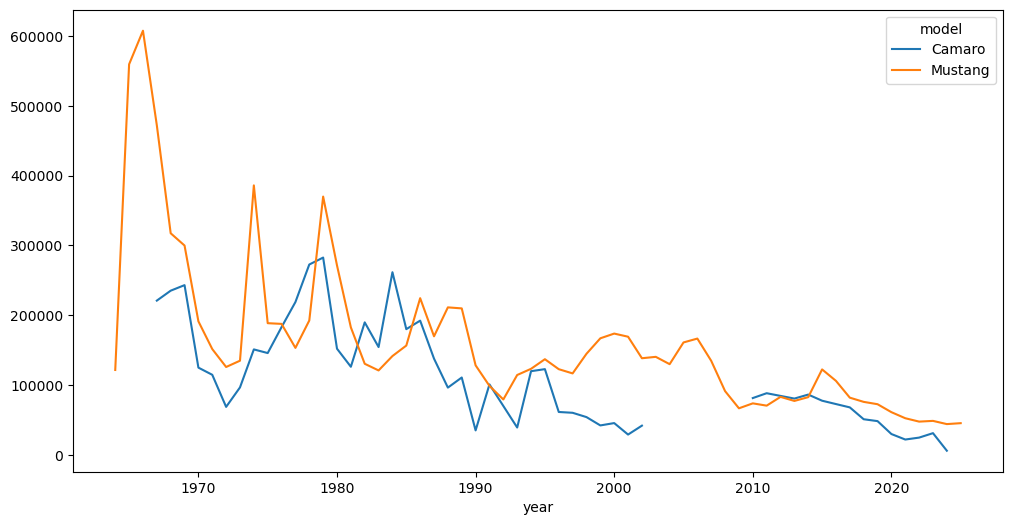

In [130]:
pivot = unified_df.pivot(index="year", columns="model", values="sales")
pivot.plot(figsize=(12,6))

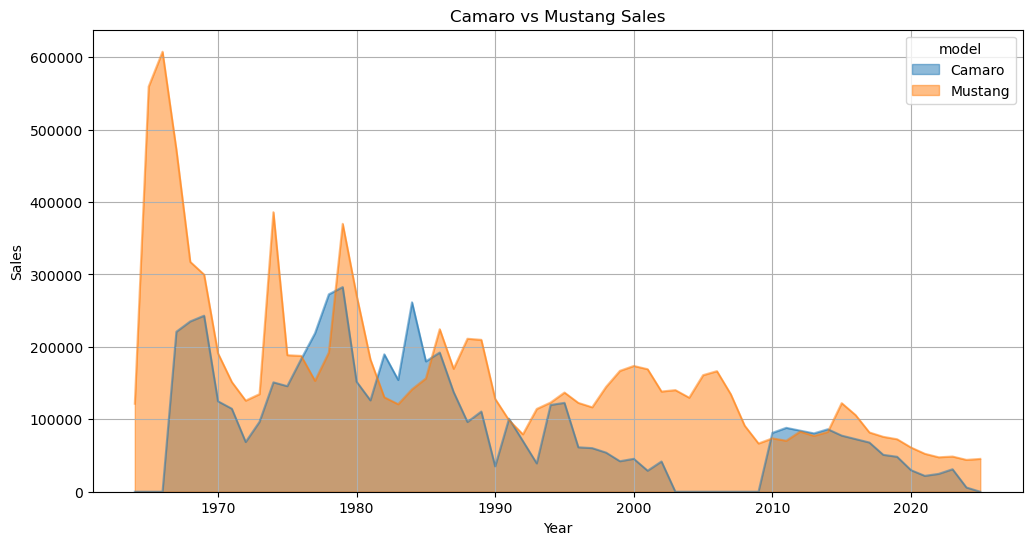

In [131]:
pivot.plot(kind="area", stacked=False, figsize=(12,6))
plt.title("Camaro vs Mustang Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)

<Axes: xlabel='generation'>

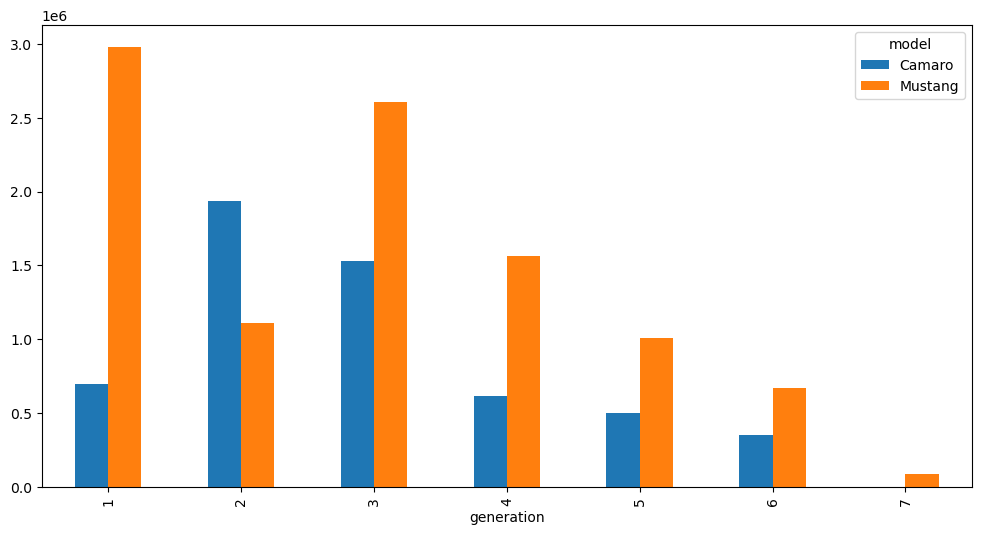

In [132]:
gen_summary = unified_df.groupby(["generation", "model"])["sales"].sum().reset_index()
gen_pivot = gen_summary.pivot(
    index="generation",
    columns="model",
    values="sales"
)
# pivot(index="generation", columns="model", values="sales")
gen_pivot.plot(
    kind="bar",
    figsize=(12,6)
)

Text(0.5, 1.0, 'Lifetime Sales Comparison')

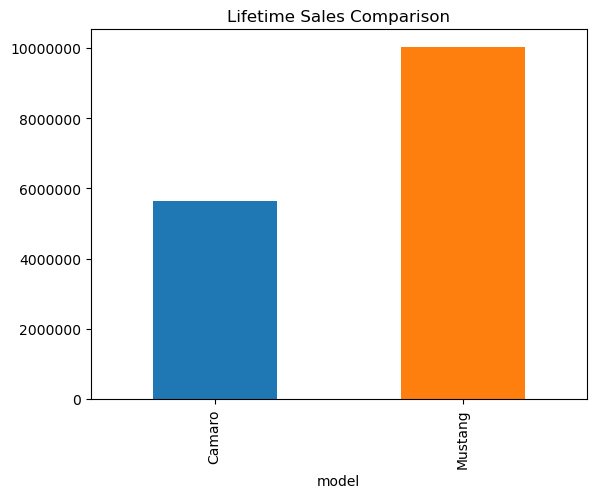

In [133]:
unified_df.groupby("model")["sales"].sum().plot(
    kind="bar",
    color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.ticklabel_format(style="plain", axis="y")
plt.title("Lifetime Sales Comparison")

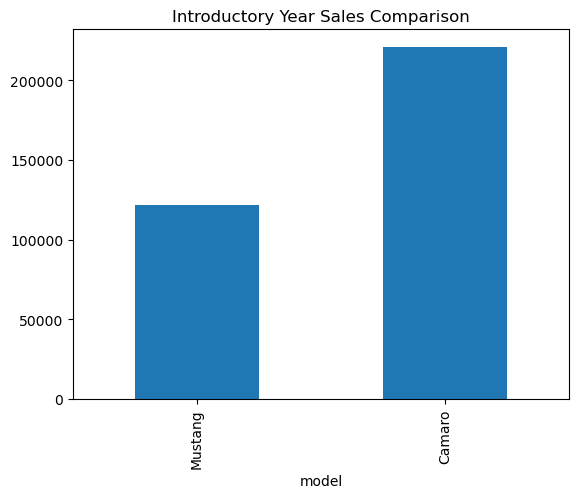

In [134]:
intro_years = unified_df.groupby("model")["year"].min()
intro_sales = unified_df.merge(
    intro_years,
    on=["model", "year"]
)[["model", "year", "sales"]]

intro_sales.plot(
    kind="bar",
    x="model",
    y="sales",
    title="Introductory Year Sales Comparison",
    legend=None
)
plt.ticklabel_format(style="plain", axis="y")

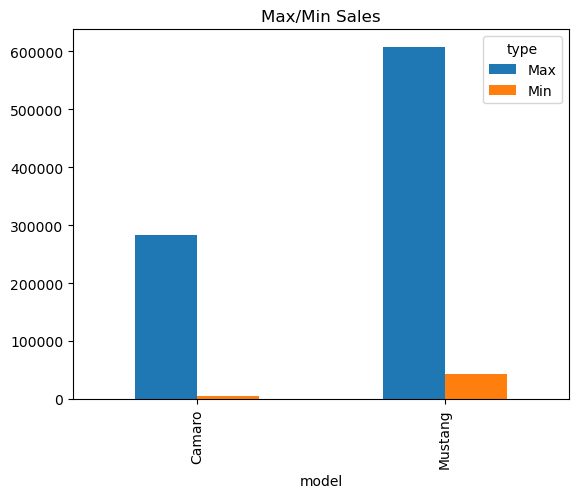

In [135]:
max_sales = unified_df.loc[
    unified_df.groupby("model")["sales"].idxmax(),
    ["model", "year", "sales"]
]

min_sales = unified_df.loc[
    unified_df.groupby("model")["sales"].idxmin(),
    ["model", "year", "sales"]
]

combined = pd.concat([
    max_sales.assign(type="Max"),
    min_sales.assign(type="Min")
]).pivot(
    index="model",
    columns="type",
    values="sales"
)

combined.plot(kind="bar", title="Max/Min Sales")
plt.ticklabel_format(style="plain", axis="y")

<Axes: title={'center': 'sales'}, xlabel='model'>

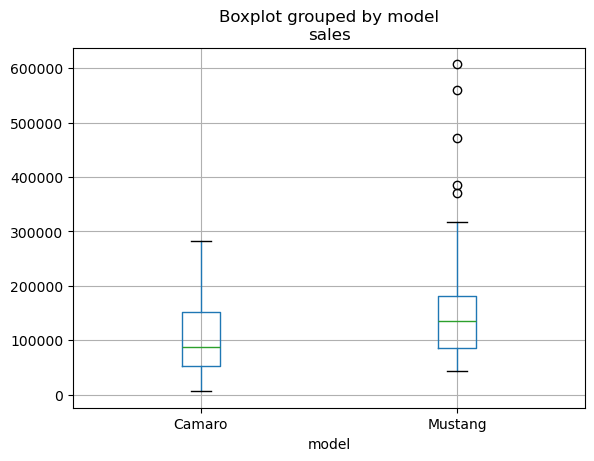

In [136]:
unified_df.boxplot(column="sales", by="model")